# Notebook 00 — Survival Analysis Primer

**Purpose**: Introduce survival analysis on the TCGA Pan-Cancer Atlas dataset before the causal inference series.  
This notebook shows *why* naive survival comparisons are biased — motivating the DAG-based approach in NB01–06.

**Figures saved**: `results/figures/00_*.png`

---
### Concept at a Glance

```
Survival data has two components per patient:
  t  = time until event or last follow-up  (OS_MONTHS)
  d  = event indicator: 1=died, 0=censored  (OS_EVENT)

Censoring: patient left study or is still alive at data cut-off.
           We know they survived at least t months — not that they survived forever.

Key methods:
  Kaplan-Meier  ->  non-parametric survival curve S(t) = P(T > t)
  Log-rank test ->  compare two KM curves (null: identical survival)
  Cox PH model  ->  hazard ratio per covariate, adjusting for others
                    h(t|X) = h0(t) * exp(beta * X)
```

**What this notebook reveals**: the naive chemo-vs-no-chemo KM comparison shows worse survival
for treated patients — the opposite of the truth. This is **indication bias** (stage confounding),
which all subsequent notebooks are designed to correct.

> Deep dive on causal structure: `../docs/concepts.md`
---

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 130, 'font.size': 10})

PARQUET = os.path.join('..', 'data', 'processed', 'analysis_dataset.parquet')
FIG_DIR = os.path.join('..', 'results', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

if not os.path.exists(PARQUET):
    raise FileNotFoundError(
        f'Dataset not found at {PARQUET}.\n'
        'Run one of:\n'
        '  python fetch_lfs_clinical.py && python build_real_dataset.py  (real TCGA data)\n'
        '  python generate_synthetic_data.py                              (synthetic fallback)'
    )

df = pd.read_parquet(PARQUET)
print(f'Loaded {len(df):,} patients, {df["CANCER_TYPE_ABBR"].nunique()} cancer types')
print(f'Event rate: {df["OS_EVENT"].mean():.1%}  |  Median OS: {df["OS_MONTHS"].median():.1f} months')
df.head(3)

Loaded 6,568 patients, 19 cancer types
Event rate: 30.4%  |  Median OS: 23.3 months


,AGE,STAGE,CANCER_TYPE_ABBR,CHEMO,TMB,OS_MONTHS,OS_EVENT
0,64.0,2.0,MESO,1.0,NaN,56.382944,1
1,60.0,3.0,MESO,0.0,NaN,11.868363,1
2,53.0,3.0,MESO,0.0,NaN,29.095572,1


## 1. Data Overview

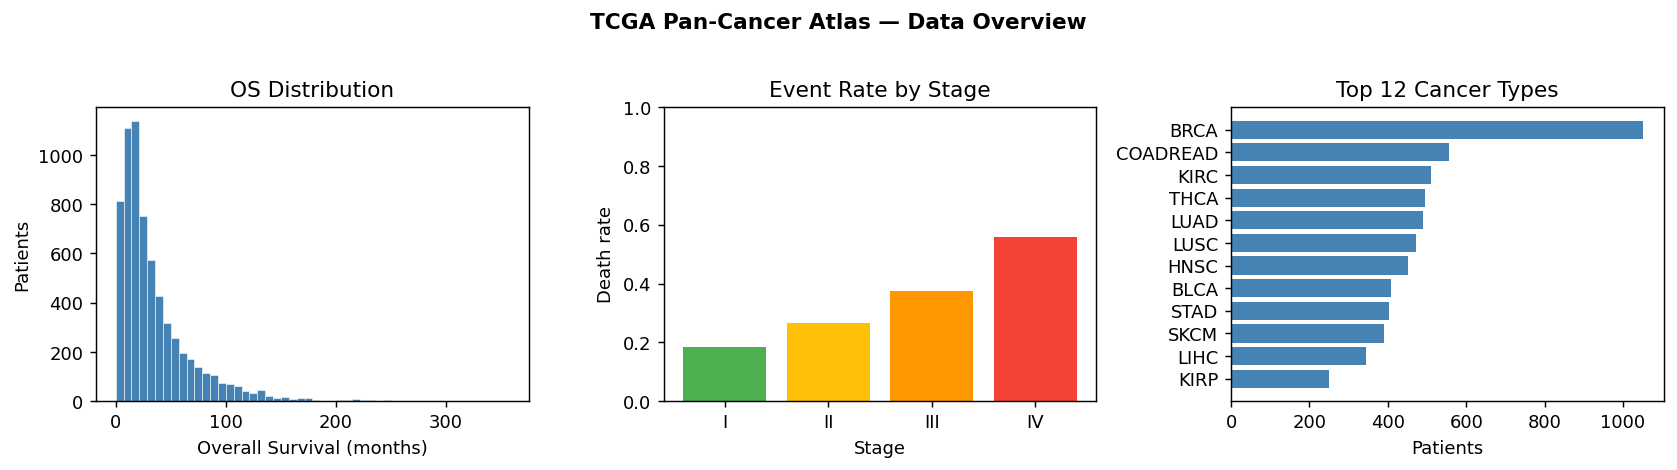

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# OS distribution
axes[0].hist(df['OS_MONTHS'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Overall Survival (months)')
axes[0].set_ylabel('Patients')
axes[0].set_title('OS Distribution')

# Event rate by stage
er = df.groupby('STAGE')['OS_EVENT'].mean().rename({1:'I',2:'II',3:'III',4:'IV'})
axes[1].bar(er.index, er.values, color=['#4CAF50','#FFC107','#FF9800','#F44336'])
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Death rate')
axes[1].set_title('Event Rate by Stage')
axes[1].set_ylim(0, 1)

# Patient counts by cancer type
ct = df['CANCER_TYPE_ABBR'].value_counts().head(12)
axes[2].barh(ct.index[::-1], ct.values[::-1], color='steelblue')
axes[2].set_xlabel('Patients')
axes[2].set_title('Top 12 Cancer Types')

plt.suptitle('TCGA Pan-Cancer Atlas — Data Overview', fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '00_data_overview.png'), bbox_inches='tight')
plt.show()

## 2. Kaplan-Meier Curves

The Kaplan-Meier estimator is the standard non-parametric method for estimating survival probability over time.
It handles censored observations correctly — patients lost to follow-up contribute information up to their last contact.

$$\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

where $d_i$ = deaths at time $t_i$, $n_i$ = patients at risk just before $t_i$.

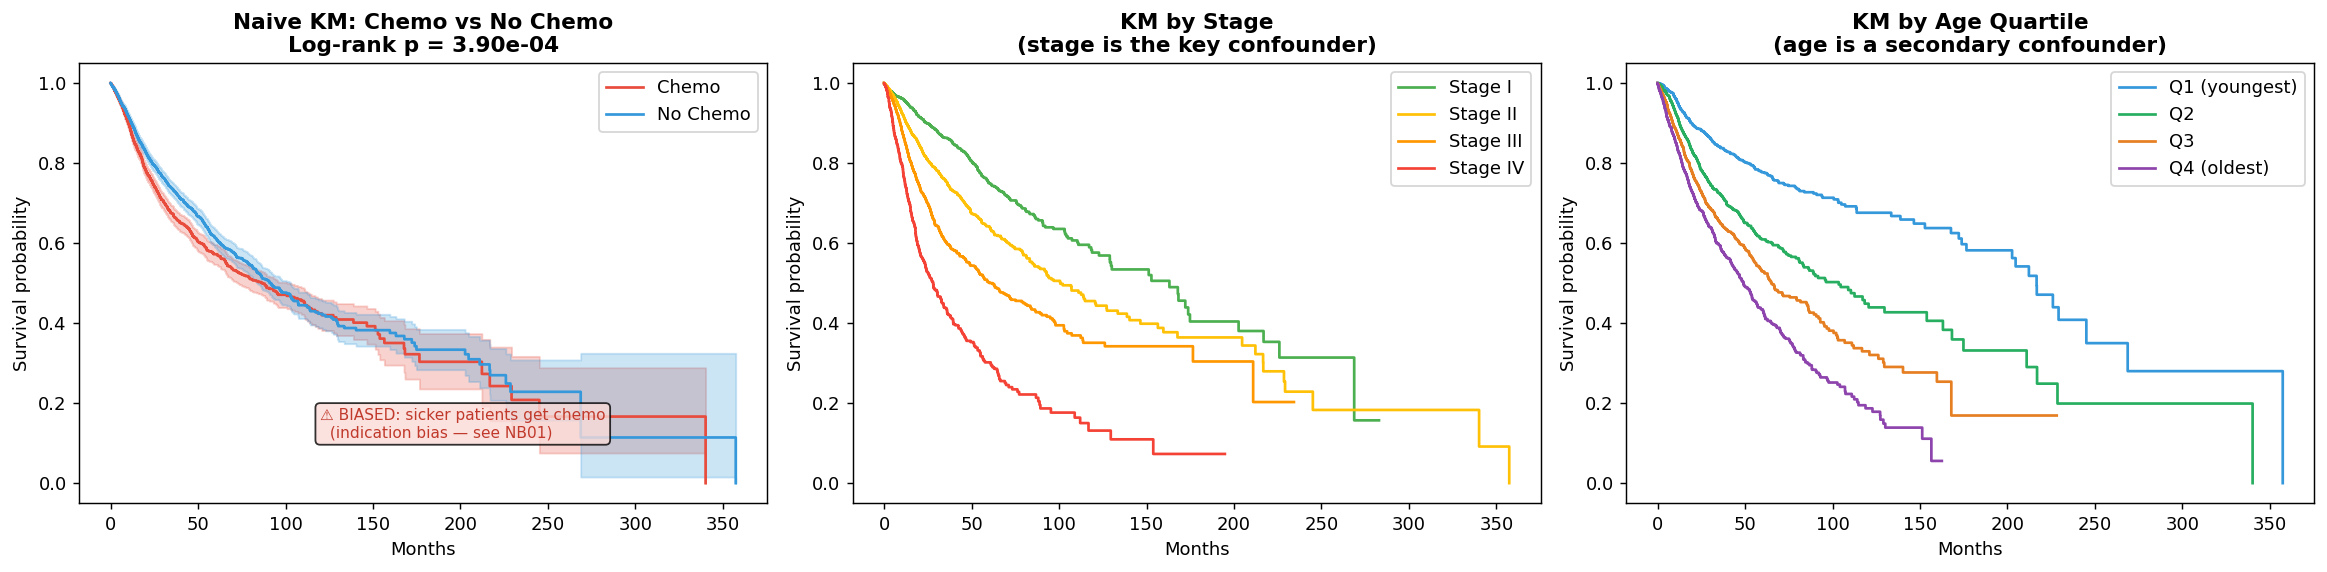

Median survival (months):
  Chemo: 86.8
  No Chemo: 90.9


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

kmf = KaplanMeierFitter()
palette = {'Chemo': '#E74C3C', 'No Chemo': '#3498DB'}

# Panel 1: Naive KM
for label, mask, color in [
    ('Chemo',    df['CHEMO'] == 1, palette['Chemo']),
    ('No Chemo', df['CHEMO'] == 0, palette['No Chemo']),
]:
    kmf.fit(df.loc[mask, 'OS_MONTHS'], df.loc[mask, 'OS_EVENT'], label=label)
    kmf.plot_survival_function(ax=axes[0], ci_show=True, color=color)

lr = logrank_test(
    df.loc[df['CHEMO']==1,'OS_MONTHS'], df.loc[df['CHEMO']==0,'OS_MONTHS'],
    df.loc[df['CHEMO']==1,'OS_EVENT'],  df.loc[df['CHEMO']==0,'OS_EVENT']
)
axes[0].set_title(f'Naive KM: Chemo vs No Chemo\nLog-rank p = {lr.p_value:.2e}', fontweight='bold')
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Survival probability')
axes[0].annotate(
    u'\u26a0 BIASED: sicker patients get chemo\n  (indication bias — see NB01)',
    xy=(0.35, 0.15), xycoords='axes fraction',
    fontsize=8.5, color='#C0392B',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FADBD8', alpha=0.8)
)

# Panel 2: KM by Stage
stage_colors = {1:'#4CAF50', 2:'#FFC107', 3:'#FF9800', 4:'#F44336'}
stage_labels = {1:'Stage I', 2:'Stage II', 3:'Stage III', 4:'Stage IV'}
for stage in [1, 2, 3, 4]:
    mask = df['STAGE'] == stage
    kmf.fit(df.loc[mask,'OS_MONTHS'], df.loc[mask,'OS_EVENT'], label=stage_labels[stage])
    kmf.plot_survival_function(ax=axes[1], ci_show=False, color=stage_colors[stage])

axes[1].set_title('KM by Stage\n(stage is the key confounder)', fontweight='bold')
axes[1].set_xlabel('Months')
axes[1].set_ylabel('Survival probability')

# Panel 3: KM by Age Quartile
df['AGE_Q'] = pd.qcut(df['AGE'], 4, labels=['Q1 (youngest)', 'Q2', 'Q3', 'Q4 (oldest)'])
age_colors = {'Q1 (youngest)':'#3498DB', 'Q2':'#27AE60', 'Q3':'#E67E22', 'Q4 (oldest)':'#8E44AD'}
for q in ['Q1 (youngest)', 'Q2', 'Q3', 'Q4 (oldest)']:
    mask = df['AGE_Q'] == q
    kmf.fit(df.loc[mask,'OS_MONTHS'], df.loc[mask,'OS_EVENT'], label=q)
    kmf.plot_survival_function(ax=axes[2], ci_show=False, color=age_colors[q])

axes[2].set_title('KM by Age Quartile\n(age is a secondary confounder)', fontweight='bold')
axes[2].set_xlabel('Months')
axes[2].set_ylabel('Survival probability')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '00_km_curves.png'), bbox_inches='tight')
plt.show()

print('Median survival (months):')
for label, mask in [('Chemo', df['CHEMO']==1), ('No Chemo', df['CHEMO']==0)]:
    kmf.fit(df.loc[mask,'OS_MONTHS'], df.loc[mask,'OS_EVENT'])
    print(f'  {label}: {kmf.median_survival_time_:.1f}')

### Why does chemo look worse?

Stage IV patients are far more likely to receive chemotherapy **and** far more likely to die.
The naive KM comparison conflates the treatment effect with the stage effect — this is **indication bias**.

The right panel confirms: stage alone explains enormous survival differences.
Any method that ignores stage will produce biased chemo estimates.

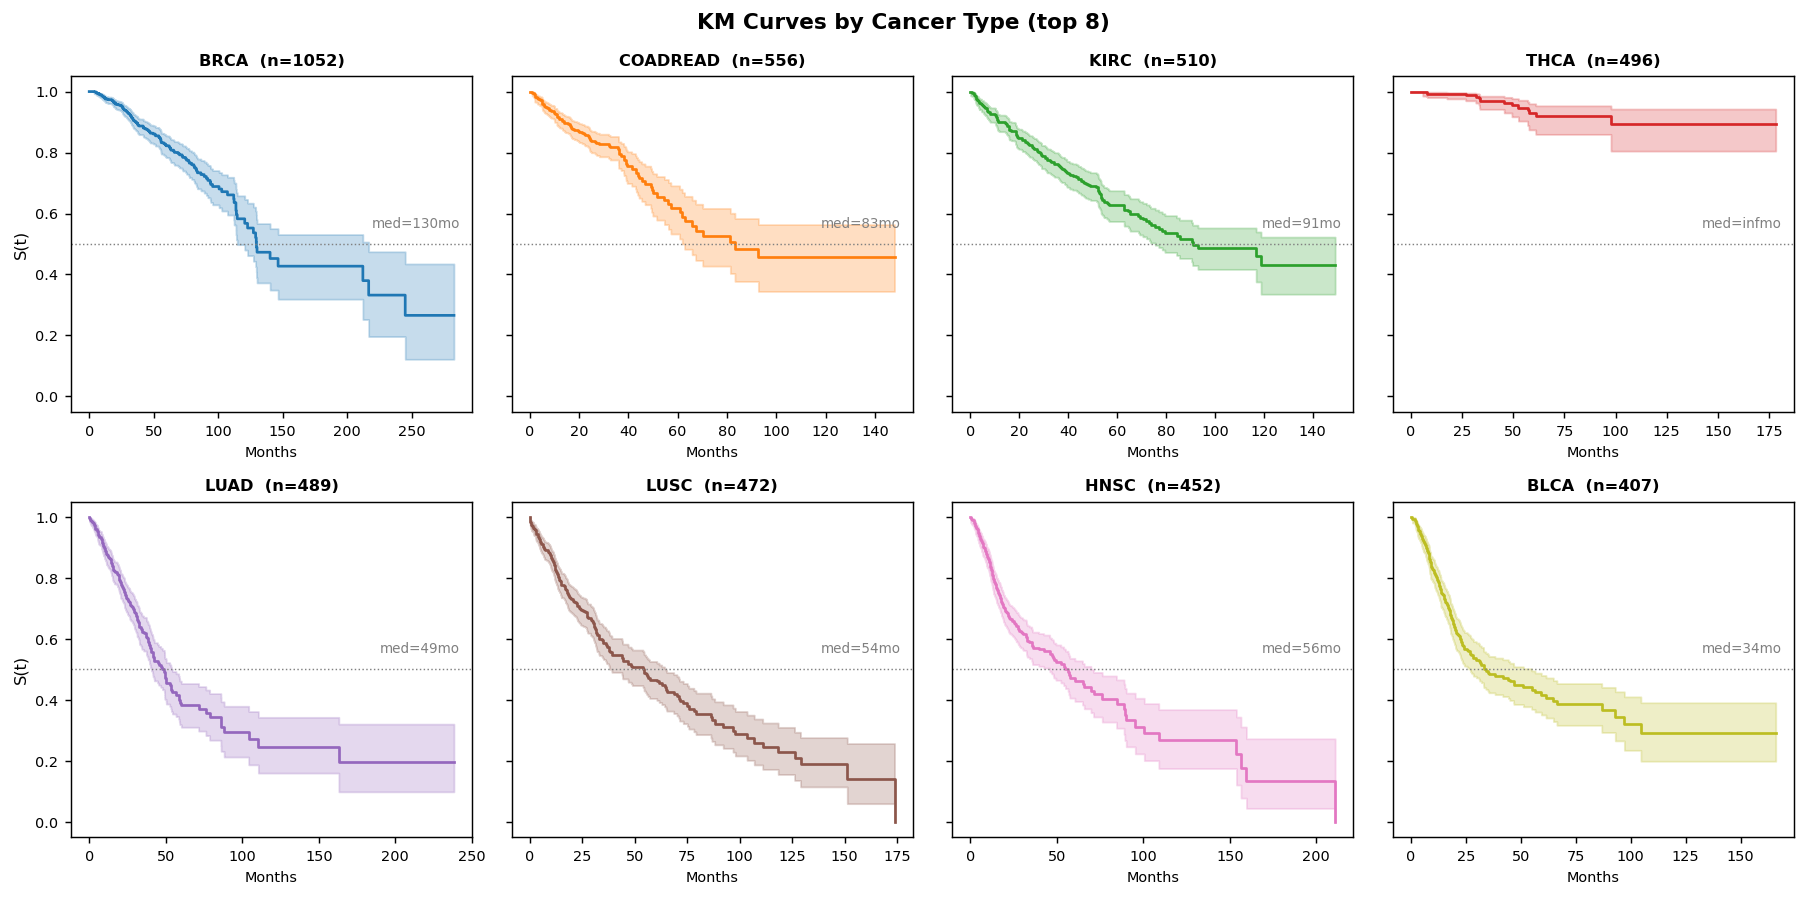

In [4]:
# KM by cancer type (top 8 by patient count)
top8 = df['CANCER_TYPE_ABBR'].value_counts().head(8).index.tolist()
sub = df[df['CANCER_TYPE_ABBR'].isin(top8)]

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharey=True)
colors = plt.cm.tab10(np.linspace(0, 0.8, 8))

for ax, ct, color in zip(axes.flat, top8, colors):
    mask = sub['CANCER_TYPE_ABBR'] == ct
    n = mask.sum()
    kmf.fit(sub.loc[mask,'OS_MONTHS'], sub.loc[mask,'OS_EVENT'])
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color, legend=False)
    ax.set_title(f'{ct}  (n={n})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months', fontsize=8)
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)
    med = kmf.median_survival_time_
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
    ax.text(0.97, 0.55, f'med={med:.0f}mo', transform=ax.transAxes,
            ha='right', fontsize=7.5, color='grey')

fig.suptitle('KM Curves by Cancer Type (top 8)', fontweight='bold')
axes[0][0].set_ylabel('S(t)', fontsize=9)
axes[1][0].set_ylabel('S(t)', fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '00_km_by_cancer_type.png'), bbox_inches='tight')
plt.show()

## 3. Cox Proportional Hazards Model

The Cox model estimates the **hazard ratio** (HR) for each covariate:
- HR > 1: higher hazard (worse survival)
- HR < 1: lower hazard (better survival)
- HR = 1: no effect

We fit two models to show how adjustment changes the chemo coefficient.

In [5]:
cox_df = df[['OS_MONTHS','OS_EVENT','CHEMO','AGE','STAGE']].dropna()
cox_df = cox_df[cox_df['OS_MONTHS'] > 0]

# Model 1: unadjusted
cph_unadj = CoxPHFitter()
cph_unadj.fit(cox_df[['OS_MONTHS','OS_EVENT','CHEMO']], 'OS_MONTHS', 'OS_EVENT')

# Model 2: adjusted for Age and Stage
cph_adj = CoxPHFitter()
cph_adj.fit(cox_df, 'OS_MONTHS', 'OS_EVENT')

print('--- Unadjusted Cox (CHEMO only) ---')
cph_unadj.print_summary(model='Unadjusted', decimals=3)
print('\n--- Adjusted Cox (CHEMO + AGE + STAGE) ---')
cph_adj.print_summary(model='Adjusted', decimals=3)

--- Unadjusted Cox (CHEMO only) ---


<lifelines.CoxPHFitter: fitted with 6568 total observations, 4570 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
      baseline estimation = breslow
   number of observations = 6568
number of events observed = 1998
   partial log-likelihood = -15965.087
         time fit was run = 2026-05-01 12:05:21 UTC
                    model = Unadjusted

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
CHEMO     0.159     1.172     0.045           0.071           0.247               1.074               1.280

           cmp to     z       p  -log2(p)
covariate                                
CHEMO       0.000 3.543 <0.0005    11.304
---
Concordance = 0.527
Partial AIC = 31932.174
log-likelihood ratio test = 12.498 on 1 df
-log2(p) of ll-ratio test = 11.261


--- Adjusted Cox (CHEMO + AGE + STAGE) ---


<lifelines.CoxPHFitter: fitted with 6568 total observations, 4570 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
      baseline estimation = breslow
   number of observations = 6568
number of events observed = 1998
   partial log-likelihood = -15537.317
         time fit was run = 2026-05-01 12:05:21 UTC
                    model = Adjusted

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
CHEMO     -0.010     0.990     0.047          -0.101           0.081               0.904               1.085
AGE        0.032     1.033     0.002           0.029           0.036               1.029               1.036
STAGE      0.479     1.615     0.023           0.434           0.525               1.544               1.690

           cmp to      z       p  -log2(p)
covariate                                 
CHEMO       0.000 -0.212   0.832     0.265
AGE         0.000 17.896 <0.0005   235.518
STAGE       0.000 20.781 <0.0005   316.209
---
Concordance = 0.692
Partial AIC = 31080.634
log-likelihood ratio test = 868.038 on 3 df
-log2(p) of ll-ratio test = 621.600

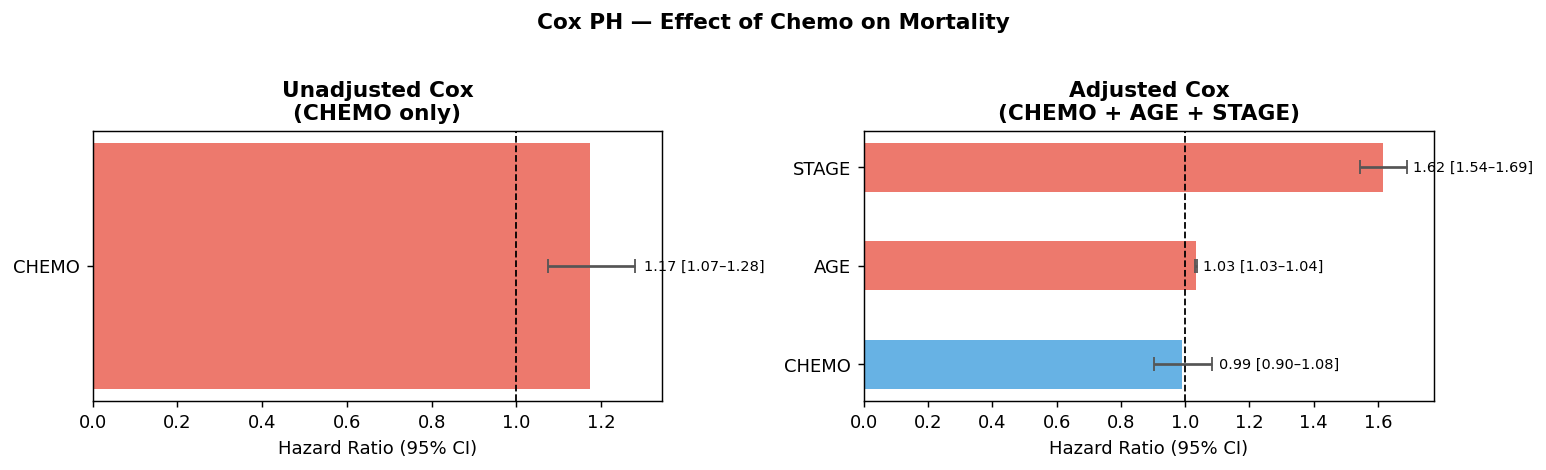

Unadjusted HR for chemo: 1.172
Adjusted HR for chemo:   0.990
Adjustment moved HR by:  +0.182 (confounding removed by adjustment)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, cph, title in [
    (axes[0], cph_unadj, 'Unadjusted Cox\n(CHEMO only)'),
    (axes[1], cph_adj,   'Adjusted Cox\n(CHEMO + AGE + STAGE)'),
]:
    summary = cph.summary
    coefs   = np.exp(summary['coef'])
    lower   = np.exp(summary['coef lower 95%'])
    upper   = np.exp(summary['coef upper 95%'])
    names   = summary.index.tolist()
    y_pos   = np.arange(len(names))

    colors_bar = ['#E74C3C' if c > 1 else '#3498DB' for c in coefs]
    ax.barh(y_pos, coefs, xerr=[coefs - lower, upper - coefs],
            color=colors_bar, alpha=0.75, capsize=4, height=0.5, ecolor='#555')
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names)
    ax.set_xlabel('Hazard Ratio (95% CI)')
    ax.set_title(title, fontweight='bold')
    for i, (hr, lo, hi) in enumerate(zip(coefs, lower, upper)):
        ax.text(hi + 0.02, i, f'{hr:.2f} [{lo:.2f}–{hi:.2f}]', va='center', fontsize=8)

plt.suptitle('Cox PH — Effect of Chemo on Mortality', fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '00_cox_comparison.png'), bbox_inches='tight')
plt.show()

unadj_hr = np.exp(cph_unadj.summary.loc['CHEMO','coef'])
adj_hr   = np.exp(cph_adj.summary.loc['CHEMO','coef'])
print(f'Unadjusted HR for chemo: {unadj_hr:.3f}')
print(f'Adjusted HR for chemo:   {adj_hr:.3f}')
print(f'Adjustment moved HR by:  {unadj_hr - adj_hr:+.3f} (confounding removed by adjustment)')

## 3b. C-index (Concordance Index)

The **C-index** (Harrell's concordance statistic) measures how well a model discriminates between patients with different survival times:

> *Of all pairs of patients where one died before the other, in what fraction did the model correctly rank the higher-risk patient as the one who died first?*

| C-index | Interpretation |
|---------|----------------|
| 0.5 | Random — no better than a coin flip |
| 0.6–0.7 | Moderate discrimination |
| 0.7–0.8 | Good discrimination |
| > 0.8 | Excellent discrimination |

Adding Stage and Age to the model should substantially improve the C-index — confirming they are genuinely prognostic.

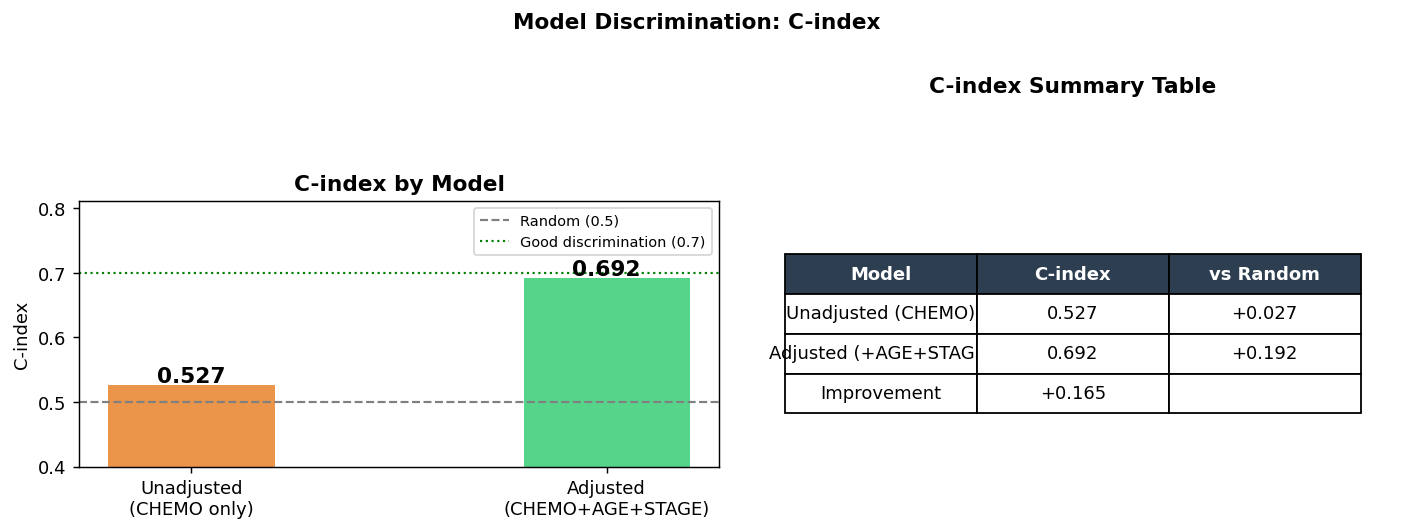

Unadjusted C-index : 0.527  — barely above random; CHEMO alone is not prognostic
Adjusted C-index   : 0.692  — good; Stage+Age drive most survival discrimination
Delta C-index      : +0.165


In [7]:
c_unadj = cph_unadj.concordance_index_
c_adj   = cph_adj.concordance_index_

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart comparison
ax = axes[0]
models = ['Unadjusted\n(CHEMO only)', 'Adjusted\n(CHEMO+AGE+STAGE)']
cvals  = [c_unadj, c_adj]
bars = ax.bar(models, cvals, color=['#E67E22', '#2ECC71'], alpha=0.82, width=0.4)
ax.axhline(0.5, color='grey',  linestyle='--', linewidth=1.2, label='Random (0.5)')
ax.axhline(0.7, color='green', linestyle=':',  linewidth=1.2, label='Good discrimination (0.7)')
ax.set_ylim(0.40, min(1.0, max(cvals) + 0.12))
ax.set_ylabel('C-index')
ax.set_title('C-index by Model', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars, cvals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.004,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)

# Interpretation panel
ax = axes[1]
ax.axis('off')
rows = [
    ['Model',              'C-index', 'vs Random'],
    ['Unadjusted (CHEMO)', f'{c_unadj:.3f}', f'+{c_unadj-0.5:.3f}'],
    ['Adjusted (+AGE+STAGE)', f'{c_adj:.3f}',   f'+{c_adj-0.5:.3f}'],
    ['Improvement',        f'+{c_adj-c_unadj:.3f}', ''],
]
tbl = ax.table(cellText=rows[1:], colLabels=rows[0],
               cellLoc='center', loc='center', bbox=[0.05, 0.2, 0.9, 0.6])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
ax.set_title('C-index Summary Table', fontweight='bold', pad=60)

plt.suptitle('Model Discrimination: C-index', fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '00_cindex.png'), bbox_inches='tight')
plt.show()

print(f'Unadjusted C-index : {c_unadj:.3f}  — barely above random; CHEMO alone is not prognostic')
print(f'Adjusted C-index   : {c_adj:.3f}  — good; Stage+Age drive most survival discrimination')
print(f'Delta C-index      : +{c_adj - c_unadj:.3f}')

## 4. Forest Plot — Cox HR by Cancer Type

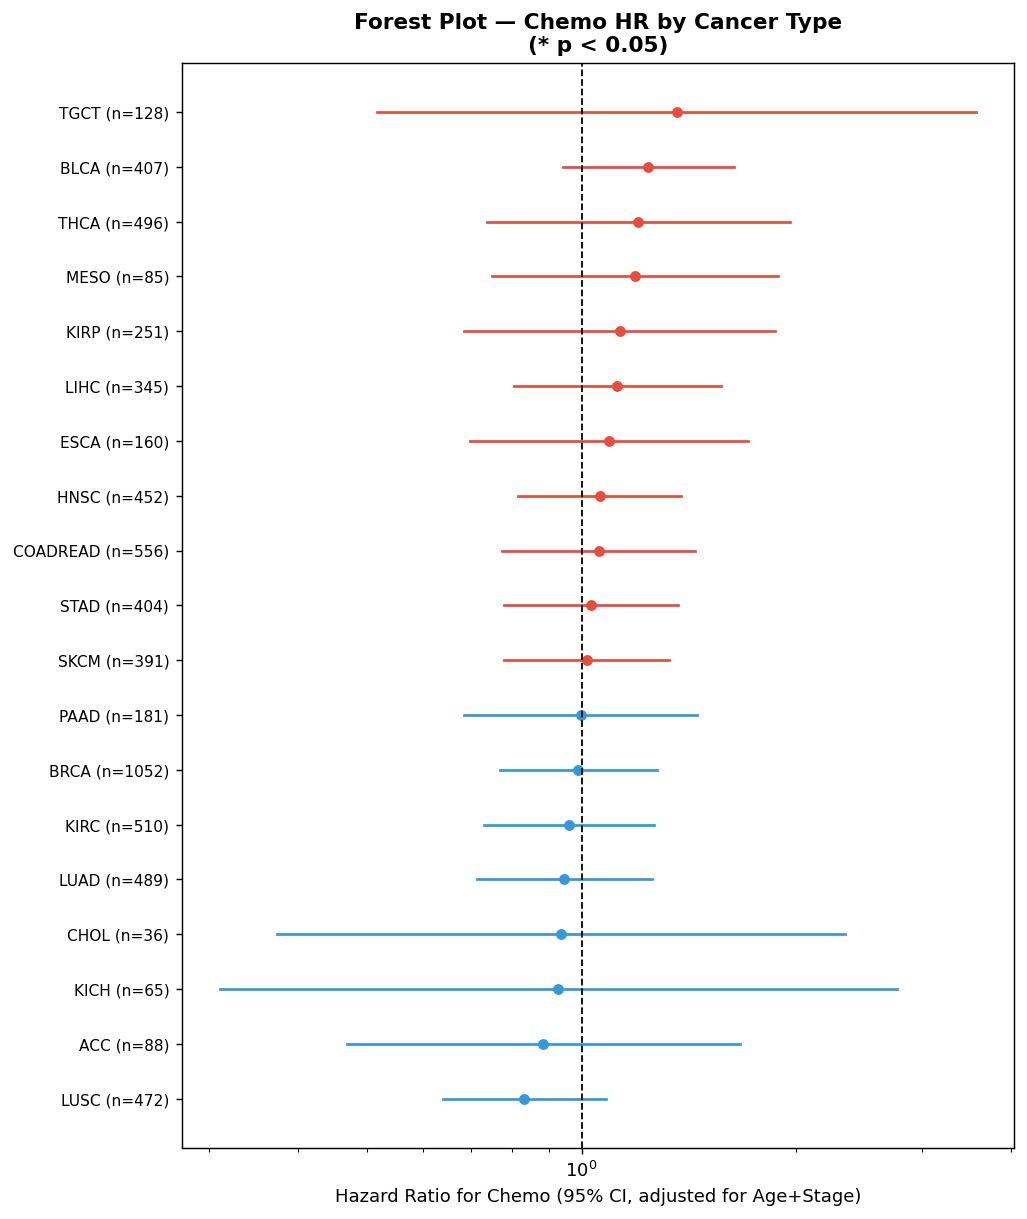

In [8]:
results = []
for ct in sorted(df['CANCER_TYPE_ABBR'].unique()):
    sub = df[df['CANCER_TYPE_ABBR'] == ct][['OS_MONTHS','OS_EVENT','CHEMO','AGE','STAGE']].dropna()
    sub = sub[sub['OS_MONTHS'] > 0]
    if sub['CHEMO'].nunique() < 2 or len(sub) < 30:
        continue
    try:
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(sub, 'OS_MONTHS', 'OS_EVENT')
        row = cph.summary.loc['CHEMO']
        results.append({
            'cancer': ct,
            'n': len(sub),
            'hr': np.exp(row['coef']),
            'lo': np.exp(row['coef lower 95%']),
            'hi': np.exp(row['coef upper 95%']),
            'p':  row['p'],
        })
    except Exception:
        pass

forest = pd.DataFrame(results).sort_values('hr')

fig, ax = plt.subplots(figsize=(8, len(forest) * 0.42 + 1.5))
y = np.arange(len(forest))

for i, row in enumerate(forest.itertuples()):
    color = '#E74C3C' if row.hr >= 1 else '#3498DB'
    ax.plot([row.lo, row.hi], [i, i], color=color, linewidth=1.5)
    marker = '*' if row.p < 0.05 else 'o'
    ax.plot(row.hr, i, marker=marker, color=color, markersize=7 if marker=='*' else 5)

ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.cancer} (n={r.n})" for r in forest.itertuples()], fontsize=8.5)
ax.set_xlabel('Hazard Ratio for Chemo (95% CI, adjusted for Age+Stage)')
ax.set_title('Forest Plot — Chemo HR by Cancer Type\n(* p < 0.05)', fontweight='bold')
ax.set_xscale('log')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '00_forest_plot.png'), bbox_inches='tight')
plt.show()

## 5. Summary and Transition to Causal Inference

| Finding | Implication |
|---------|-------------|
| Naive KM shows chemo patients have **worse** survival | Indication bias — sicker patients get treated |
| Stage IV has dramatically worse prognosis | Stage is a strong confounder |
| Adjusted Cox HR changes after adding Stage+Age | Confirms confounding was present |
| HR varies across cancer types | Effect heterogeneity — pooled estimate may be misleading |

### What the Cox model still cannot do:
- It can only adjust for **measured** confounders. If performance status, comorbidities,
  or patient preference are unmeasured, the HR is still biased.
- It cannot tell us whether the effect **operates through TMB** or directly.
- It cannot test whether the finding is robust to hidden confounding.

**That is exactly what NB01–06 address:**

```
NB01 → Which confounders? (DAG)      NB04 → How? (Mediation)
NB02 → How large? (PSM)              NB05 → Hidden confounders? (IV)
NB03 → Confirmed? (DiD)              NB06 → How robust? (Sensitivity)
```